# Biopython으로 라이노바이러스 서열 분석해보기
## 개요
아니 얘는 또 뭐 하는 앱니까? 여러분들, 감기랑 독감이랑 원인균 다른거 아셨습니까? 독감은 인플루엔자가 범인이고 일반 감기는 라이노바이러스가 원인입니다. 

## 감기에는 진짜로 약이 없다
아니 뭔 소리임? 우리 감기약 먹잖아요! 그건 증상을 완화시켜서 면역계가 바이러스를 쫓아내는 걸 **도와주는**겁니다. 감기 바이러스를 직접 공격하는 약은 없어요. 왜냐고요? 감기 바이러스는 변이율이 진짜 장난아니거든요! 눈 깜빡할 새에 변이합니다. 그래서 감기약은 바이러스를 공격하는 원딜이 아니라 우리편을 도와주는 서폿입니다. 

## 프로젝트 정보
- 인원: 1인(개인 프로젝트)
- 버전: 3.10(TF_base)
- 설치할 것들: Biopython, muscle
- 데이터 리소스: NCBI(Entrez로 갖고올 예정)

In [22]:
# 모듈
import numpy as np
import matplotlib.pyplot as plt
import math

# Biopython
from Bio import Entrez, SeqIO # 왼쪽: 일단 털어보자/오른쪽: 시퀀스 다루려면 필요합니다. 필수임. 
from Bio import AlignIO # 서열 분석해줄 친구
from Bio import Phylo # 트리 그릴라면 필요해요 
from Bio.Align import AlignInfo
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor
from Bio.Seq import Seq

import io # 누구세요?
import subprocess # 서브 프로세스(이건 또 뭐여...)
from collections import defaultdict

# 통계분석용
from scipy.stats import mannwhitneyu
from itertools import combinations

In [3]:
# 그래프를 그리기 위한 기본 설정
plt.rcParams['font.family'] = 'Nanumsquare_ac' # 나눔바른펜(본인 기본 고딕 싫어함)
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 사전세팅
Entrez.email = "blackholekun@gmail.com" # 이메일 
muscle_exe = "/opt/homebrew/bin/muscle" # 이거 경로 있어야 써요(which 치면 나옴)

# 창고가 열려있으면 털어주는게 인지상정! 
- 여기서는 라이노바이러스의 VP1로 진행하겠습니다. 

In [13]:
# 바이러스 서열 다운로드
# 이게 근데 막 받으면 안되거든요? 한타바이러스 식구들은 둘쨰치고 저기가 데이터가 진짜 방대해요. 
virus_query = "Rhinovirus[Organism] AND VP1 AND complete cds AND 7000:7500[Sequence Length]"

print('Searching sequences... ') # 솔직히 이거 없으면 되는건지 불안하잖아요...

handle = Entrez.esearch(db="nucleotide", term=virus_query, retmax=20)
record = Entrez.read(handle)
id_list = record['IdList']

print(f"총 {len(id_list)}개의 표준 서열을 찾았습니다.")

Searching sequences... 
총 20개의 표준 서열을 찾았습니다.


In [14]:
# 콤퓨타에 저-장
vir_sequence = []
for i, id in enumerate(id_list):
    print(f"Downloading sequence {i+1}/{len(id_list)}: {id}")
    handle = Entrez.efetch(db="nucleotide", id=id, rettype="fasta", retmode="text")
    record = SeqIO.read(handle, "fasta")
    
    # record에 id와 seq가 다 들어가야되더라... (안되면 오류남 봤음)
    vir_sequence.append(record) 

# 파일로 저장
SeqIO.write(vir_sequence, "rhinovirus_sequence_20.fasta", "fasta")
print('Done!')

Done!


In [15]:
# 시퀀스 길이 체크 
for rec in vir_sequence:
    print(f"ID: {rec.id} | Length: {len(rec.seq)}")

ID: PX056340.1 | Length: 7266
ID: PX725683.1 | Length: 7439
ID: PX725678.1 | Length: 7500
ID: PX725677.1 | Length: 7439
ID: PX725676.1 | Length: 7439
ID: PX725675.1 | Length: 7439
ID: PX725674.1 | Length: 7439
ID: PX725673.1 | Length: 7439
ID: PX725672.1 | Length: 7439
ID: PX725671.1 | Length: 7439
ID: PX471053.1 | Length: 7412
ID: PX056678.1 | Length: 7304
ID: PQ273608.1 | Length: 7437
ID: PQ273607.1 | Length: 7436
ID: PP873675.1 | Length: 7442
ID: PV604349.1 | Length: 7051
ID: PV604347.1 | Length: 7346
ID: PV604345.1 | Length: 7008
ID: PQ641085.1 | Length: 7408
ID: PV563579.1 | Length: 7322


# MSA
- 머슬 썼습니다. (clustalW 아마 깔려는 있을듯)

In [17]:
print('MSA start... ')

# MSA 분석 시-작
try: 
    result = subprocess.run([muscle_exe, "-align", "rhinovirus_sequence_20.fasta", "-output", "rhinovirus_muscle_aligned.fasta"], check=True, capture_output=True, text=True)
    print("Completed. ")
except subprocess.CalledProcessError as e: 
    print(f"MSA failed: {e}")
finally:
    alignment = AlignIO.read("influenza_h3n2_muscle_aligned.fasta", "fasta")

# 밥 먹고 오면 끝나있겠는데...? 

MSA start... 
Completed. 


In [18]:
print("====== MSA Result ======")
alignment = AlignIO.read("influenza_h3n2_muscle_aligned.fasta", "fasta") # FASTA 니네 확장자가 몇개냐... 

for record in alignment:
    print(f"{record.id[:10]:<15} : {record.seq[:100]}")

====== MSA Result ======
OP847931.1      : ---------------------------------ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCGCTCAAAAAATTCCTGGAAATG
OP847971.1      : ---------------------------------ATGAAGACTATCATTGCTTTGAGCTACACTCTATGTCTGGTTTTCGCTCAAAAAATTCCTGGAAATG
OP847947.1      : ---------------------------------ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCGCTCAAAAAATTCCTGGAAATG
PQ483286.1      : ------------------------------------------------------------------TGTCTGGTTTTCACTCAAAAAATTCCTGGAAATG
PX759059.1      : ---------------------------------ATGAAGGCTATCATTGCTTTGAGCAACATTCTATGTCTTGTTTTCGCTCAAAAAATACCTGGAAATG
PX759051.1      : ---------------------------------ATGAAGGCTATCATTGCTTTGAGCAACATTCTATGTCTTGTTTTCGCTCAAAAAATACCTGGAAATG
OP847923.1      : ---------------------------------ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCGCTCAAAAAATTCCTGGAAATG
PX782326.1      : ---------------------------------ATGAAGGCTATCATTGCTTTGAGCAACATTCTATGTCTTGTTTTCGCTCAAAACATACCTGGAAATG
PX710628.1      : -----

In [19]:
# 코어 시퀀스는 어디? (바이러스라고 앞뒤 안가리고 다 변형하는거 아님)
def calculate_conservation(alignment):
    length = alignment.get_alignment_length()
    scores = []
    for i in range(length):
        column = alignment[:, i]
        most_common = max(column, key=column.count)
        score = column.count(most_common) / len(column)
        scores.append(score)
    return scores

scores = calculate_conservation(alignment)

print(f"해당 구간의 평균 보존율: {np.mean(scores)*100:.2f}%")

해당 구간의 평균 보존율: 98.41%


# 섀넌 앤트로피

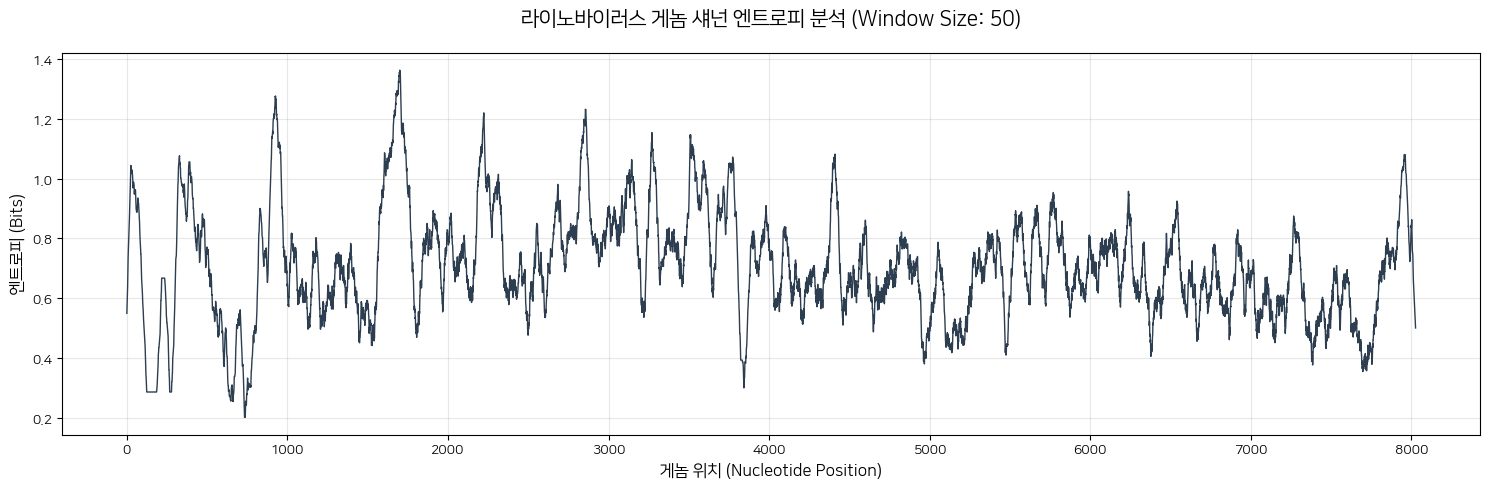

In [25]:
def calculate_shannon_entropy(alignment):
    entropy_list = []
    num_sequences = len(alignment)
    alignment_length = alignment.get_alignment_length()

    for i in range(alignment_length):
        column = alignment[:, i]
        # 각 염기(A, C, G, T, -)의 빈도 계산
        counts = {base: column.count(base) for base in "ACGT-"}
        entropy = 0
        for base in counts:
            p = counts[base] / num_sequences
            if p > 0:
                entropy -= p * math.log2(p)
        entropy_list.append(entropy)
    return entropy_list

# 1. MSA 결과 불러오기 (파일명을 맞춰주세요)
alignment = AlignIO.read("rhinovirus_muscle_aligned.fasta", "fasta")
entropy_values = calculate_shannon_entropy(alignment)

# 2. Sliding Window로 평활화 (가독성 향상)
window_size = 50
smoothed_entropy = np.convolve(entropy_values, np.ones(window_size)/window_size, mode='same')

# 3. 시각화 (NanumSquare 반영)
plt.figure(figsize=(15, 5))
plt.plot(smoothed_entropy, color='#2c3e50', linewidth=1)
plt.title(f'라이노바이러스 게놈 섀넌 엔트로피 분석 (Window Size: {window_size})', fontsize=15, pad=20)
plt.xlabel('게놈 위치 (Nucleotide Position)', fontsize=12)
plt.ylabel('엔트로피 (Bits)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

- 한타바이러스거 그대로 갖다썼더니 풀로 안보여주데... 

## 통계분석
- 귀무가설: 라이노바이러스의 변이는 무작위적으로 발생하며, 특정 위치에 선호적으로 집중되지 않는다.
- 대립가설: 라이노바이러스의 변이는 무작위가 아니며, 특정 위치(hotspots)에 유의하게 집중된다.

In [28]:
# 여러분 이것도 통계분석이 됩니다. 
variation_scores = np.array(variation_scores)

mean_var = np.mean(variation_scores)
median_var = np.median(variation_scores)
iqr_var = np.percentile(variation_scores, 75) - np.percentile(variation_scores, 25)

print(f"Mean variation score: {mean_var:.4f}")
print(f"Median variation score: {median_var:.4f}")
print(f"IQR: {iqr_var:.4f}")

Mean variation score: 0.0159
Median variation score: 0.0000
IQR: 0.0033


In [29]:
# Define high-variation hotspots (top 10%)
threshold = np.percentile(variation_scores, 90)

hotspots = variation_scores[variation_scores >= threshold]
non_hotspots = variation_scores[variation_scores < threshold]

u_stat, p_value = mannwhitneyu(
    hotspots,
    non_hotspots,
    alternative="greater"
)

print(f"Hotspot threshold (90th percentile): {threshold:.4f}")
print(f"Mann–Whitney U statistic: {u_stat:.1f}")
print(f"p-value: {p_value:.4e}") # 아 이거는 제가 소수점 조절을 못했어요... 하면 큰일나... 

Hotspot threshold (90th percentile): 0.0133
Mann–Whitney U statistic: 324480.0
p-value: 7.0952e-172


# Phylogenic tree

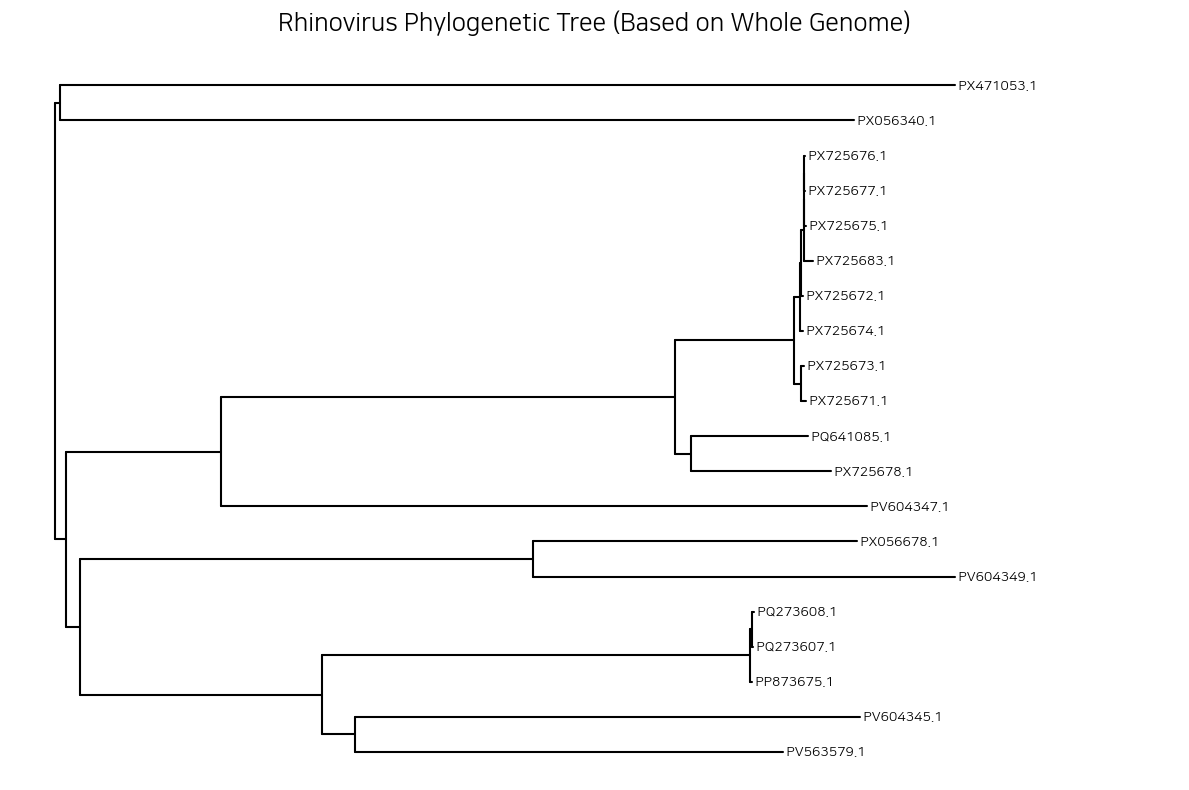

In [27]:
# 1. 거리 행렬 계산 (Identity 모델 사용)
calculator = DistanceCalculator('identity')
dm = calculator.get_distance(alignment)

# 2. Neighbor-Joining(NJ) 트리 생성
constructor = DistanceTreeConstructor(calculator, 'nj')
tree = constructor.build_tree(alignment)
tree.root_at_midpoint() # 루트를 중간으로 잡아 균형 잡힌 트리 생성

# 3. 시각화 (NanumSquare 폰트가 이미 글로벌 설정되어 있으므로 바로 출력!)
fig = plt.figure(figsize=(12, 8), dpi=100)
ax = fig.add_subplot(1, 1, 1)
plt.title("Rhinovirus Phylogenetic Tree (Based on Whole Genome)", fontsize=18, pad=20)

# Bio.Phylo를 이용한 트리 드로잉
Phylo.draw(tree, axes=ax, do_show=False, label_func=lambda n: str(n) if n.is_terminal() else "")

# 후처리: 축 숨기기 등 깔끔하게 정리
plt.axis('off')
plt.tight_layout()
plt.show()

## 통계분석
- 귀무가설: 동일 clade 내 서열 유사도와 서로 다른 clade 간 서열 유사도에는 차이가 없다.
- 대립가설: 동일 clade 내 서열 유사도가 clade 간 서열 유사도보다 유의하게 높다.

In [30]:
def pairwise_identity(seq1, seq2):
    matches = sum(a == b for a, b in zip(seq1, seq2) if a != '-' and b != '-')
    length = sum(a != '-' and b != '-' for a, b in zip(seq1, seq2))
    return matches / length if length > 0 else 0

def extract_clades(tree, cutoff=0.05):
    clade_map = {}
    clade_id = 0

    for clade in tree.find_clades():
        if clade.branch_length and clade.branch_length > cutoff:
            terminals = clade.get_terminals()
            for t in terminals:
                clade_map[t.name] = f"Clade_{clade_id}"
            clade_id += 1

    return clade_map

In [31]:
clade_map = extract_clades(tree, cutoff=0.05)

# ID 정규화 (이거 중요)
normalized_clade_map = {}
for k, v in clade_map.items():
    normalized_clade_map[k.split('.')[0]] = v

In [32]:
within_clade = []
between_clade = []

for rec1, rec2 in combinations(alignment, 2):
    id1 = rec1.id.split('.')[0]
    id2 = rec2.id.split('.')[0]

    if id1 not in normalized_clade_map or id2 not in normalized_clade_map:
        continue

    identity = pairwise_identity(str(rec1.seq), str(rec2.seq))

    if normalized_clade_map[id1] == normalized_clade_map[id2]:
        within_clade.append(identity)
    else:
        between_clade.append(identity)

print(len(within_clade), len(between_clade))

48 142


In [33]:
u, p = mannwhitneyu(
    within_clade,
    between_clade,
    alternative="greater"
)

print(f'U-statistic: {u:.1f}')
print(f'p-value: {p:.4e}') # 그... 이게... 맞아요? 

U-statistic: 6816.0
p-value: 2.1869e-25


### 이펙트 사이즈

In [34]:
effect_size = (
    np.median(within_clade) - np.median(between_clade)
)

print(f'effect_size: {effect_size:.4f}')

effect_size: 0.3878


In [35]:
n1 = len(within_clade)
n2 = len(between_clade)

rbc = 1 - (2 * u) / (n1 * n2)
print(f"Rank-biserial r: {rbc:.4f}")

Rank-biserial r: -1.0000
